In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

from shapely.geometry import Polygon, Point, box
import re
from datetime import datetime, timedelta

import matplotlib.pyplot as plt

%cd ..

c:\Users\javie\Documents\magister\propagacion-incendios


C:\Users\javie\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
conaf_2017 = r'data\raw\conaf\if_magnitud_2016_2017'

##### incendio las maquinas

In [ ]:
gdf = gpd.read_file(conaf_2017)

In [14]:
mega_incendio = gdf[gdf.NOM_INCEN == '320_LAS MAQUINAS']

In [16]:
mega_incendio.explore()

In [18]:
mega_incendio.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
gdf_proj = mega_incendio.to_crs(epsg=3857)

In [ ]:
minx, miny, maxx, maxy = gdf_proj.total_bounds

## add buffer de 2km
buffer_m = 2000
bbox_buffered = box(minx - buffer_m, miny - buffer_m, maxx + buffer_m, maxy + buffer_m)

In [ ]:
gdf_bbox = gpd.GeoDataFrame(geometry=[bbox_buffered], crs=gdf_proj.crs)
gdf_bbox_latlon = gdf_bbox.to_crs(epsg=4326)

In [ ]:
convex = gdf_proj.unary_union.convex_hull
convex_buffered = convex.buffer(buffer_m)

C:\Users\javie\AppData\Local\Temp\ipykernel_27100\251137952.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex = gdf_proj.unary_union.convex_hull


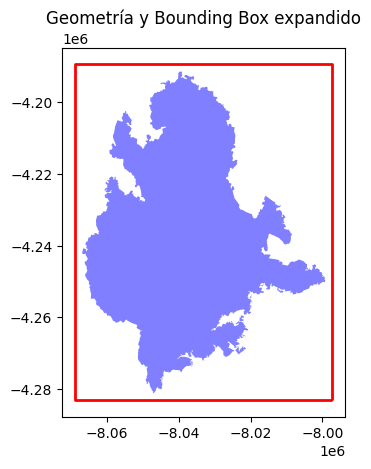

In [23]:
fig, ax = plt.subplots()
gdf_proj.plot(ax=ax, color='blue', alpha=0.5)
gdf_bbox.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
plt.title("Geometría y Bounding Box expandido")
plt.show()

In [25]:
gdf_bbox.to_file("data/procesado/areas/las_maquinas.geojson", driver="GeoJSON")

##### incendio de 2023

Biobío	Biobio	Nacimiento	37°26'11" S	72°50'59" O	Conaf	801	SANTA ANA	2-feb-2023 17:21	6-abr-2023 18:44	69.080,51

In [15]:
conaf_2023 = r'data\raw\conaf\if_magnitud_2022_2023'
gdf = gpd.read_file(conaf_2023)

In [21]:
incendio_santa_ana = gdf[gdf.NOM_INCEN == 'SANTA ANA']

In [22]:
incendio_santa_ana.explore()

In [23]:
gdf_proj = incendio_santa_ana.to_crs(epsg=3857)
minx, miny, maxx, maxy = gdf_proj.total_bounds

## add buffer de 2km
buffer_m = 2000
bbox_buffered = box(minx - buffer_m, miny - buffer_m, maxx + buffer_m, maxy + buffer_m)

gdf_bbox = gpd.GeoDataFrame(geometry=[bbox_buffered], crs=gdf_proj.crs)
gdf_bbox_latlon = gdf_bbox.to_crs(epsg=4326)

convex = gdf_proj.unary_union.convex_hull
convex_buffered = convex.buffer(buffer_m)

C:\Users\javie\AppData\Local\Temp\ipykernel_17700\3323889946.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex = gdf_proj.unary_union.convex_hull


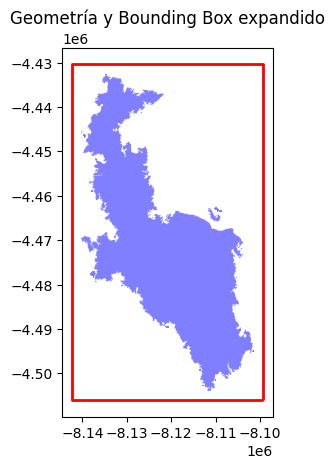

In [24]:
fig, ax = plt.subplots()
gdf_proj.plot(ax=ax, color='blue', alpha=0.5)
gdf_bbox.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
plt.title("Geometría y Bounding Box expandido")
plt.show()

In [25]:
gdf_bbox = gdf_bbox.to_crs(epsg=4326)
gdf_bbox.to_file("data/procesado/areas/santa_ana_2023.geojson", driver="GeoJSON")